In [159]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Word2Vec
from kneed import KneeLocator
from gensim import corpora
import numpy as np
import re
import pandas as pd


import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN



In [2]:
# === Download necessary NLTK data ===
# nltk.download("punkt")
# nltk.download("stopwords")
# nltk.download("wordnet")

FINE_TUNED_DIR = '../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

# === Constants ===
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
CONST_VECTOR_SIZE = 50
CONST_DIM_WINDOWS = 3

In [7]:
def advanced_clean_text(text):
    if not isinstance(text, str):
        return "other"  # Handle non-string values safely
    
    # Define domain-specific stopwords
    custom_stopwords = {'point', 'points', 'interest', 'landmark', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations

    words = text.split()  # ✅ Fix: Use split() instead of word_tokenize()
    words = [LEMMATIZER.lemmatize(word) for word in words if word not in STOPWORDS]
    words = [word for word in words if word not in custom_stopwords and word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)  

In [4]:
combined_details_df = pd.read_parquet("../../frontend/inputs/combined_details.parquet")

In [5]:
combined_details_df.head(5)

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,456633,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,34,210,363,413,"History Museums, Specialty Museums",105,440,9,148,184
1,23933132,Opium Bar,None,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,0,4,Bars & Clubs,0,3,0,0,2
2,7099963,Wat Phra That Doi Saket,None,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,None,https://www.tripadvisor.com/UserReview-g196165...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,5,31,44,Sacred & Religious Sites,9,26,0,14,21
3,1390125,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,43,98,127,102,Boat Tours,31,186,2,43,57
4,547675,Pai River,None,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,None,https://www.tripadvisor.com/UserReview-g303916...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,6,46,58,52,Bodies of Water,30,56,1,15,46


In [6]:
combined_details_df['tags'] = combined_details_df['tags'].fillna("").astype(str)
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_9392/4017882174.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [8]:
combined_details_df['label'] = combined_details_df['tags'].apply(lambda x: x.split(',')[0])

In [9]:

combined_details_df['tags'] = combined_details_df['tags'].apply(advanced_clean_text)
combined_details_df['tags']

0               history museum specialty museum
1                                      bar club
2                              sacred religious
3                                     boat tour
4                                    body water
                         ...                   
1761                                      beach
1762                                     bridge
1763    sacred religious architectural building
1764                                      beach
1765                                    lookout
Name: tags, Length: 1766, dtype: object

In [10]:
combined_details_df['label'] = combined_details_df['label'].apply(advanced_clean_text)
combined_details_df['label'] = combined_details_df['label'].fillna("").astype(str)
combined_details_df['label'].replace("", "other", inplace=True)
combined_details_df['label']

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_9392/348596639.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['label'].replace("", "other", inplace=True)


0         history museum
1               bar club
2       sacred religious
3              boat tour
4             body water
              ...       
1761               beach
1762              bridge
1763    sacred religious
1764               beach
1765             lookout
Name: label, Length: 1766, dtype: object

In [11]:
# แปลงข้อมูลเป็น String
tags = combined_details_df['tags'].astype(str)

# ใช้ TF-IDF Vectorizer
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.lower().split(" "), stop_words='english')

# Fit Transform
X = vectorizer.fit_transform(tags)

# ดึง Feature Names (คำที่สำคัญ)
feature_names = np.array(vectorizer.get_feature_names_out())

# คำนวณ TF-IDF และเลือกคำที่มีค่ามากที่สุดในแต่ละแถว
important_words = []
for row in X:
    row_data = row.toarray().flatten()
    best_word_index = np.argmax(row_data)  # Index ของคำที่สำคัญที่สุด
    best_word = feature_names[best_word_index] if row_data[best_word_index] > 0 else None
    important_words.append(best_word)

# เพิ่มคอลัมน์ใหม่
combined_details_df["keyword"] = important_words

# ดูผลลัพธ์
(combined_details_df[["name", "tags", "keyword"]].head(10))

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,name,tags,keyword
0,House of Opium,history museum specialty museum,museum
1,Opium Bar,bar club,bar
2,Wat Phra That Doi Saket,sacred religious,religious
3,Mae Ping River Cruise,boat tour,boat
4,Pai River,body water,body
5,Doi Chang Mub Arboretum,lookout,lookout
6,Tung Dok Bua Tong Doi Hua Mae Kum,garden,garden
7,Golden Triangle,,
8,Golden Triangle Tours - Day Tours,sightseeing tour,sightseeing
9,Bo Nam Ron Krung Ching,hot spring geyser,geyser


In [12]:
from collections import Counter

# รวมแท็กทั้งหมดเป็น List (แก้เป็น .split(", ") แทน .split(" "))
all_tags = [tag.strip() for tags in combined_details_df['tags'].dropna() for tag in tags.lower().split(", ")]

# นับความถี่ของแต่ละคำ
tag_counts = Counter(all_tags)

# ฟังก์ชันเลือกคำที่พบบ่อยที่สุดในแถว
def select_most_frequent(tag_string):
    tags = tag_string.lower().split(", ")  # แก้ให้แยกคำตาม ", "
    return max(tags, key=lambda tag: tag_counts[tag]) if tags else None

# ใช้ฟังก์ชันกับทุกแถว
combined_details_df["frequncy_keyword"] = combined_details_df["tags"].astype(str).apply(select_most_frequent)

# ดูผลลัพธ์
print(combined_details_df[["tags", "frequncy_keyword"]].head())

                              tags                 frequncy_keyword
0  history museum specialty museum  history museum specialty museum
1                         bar club                         bar club
2                 sacred religious                 sacred religious
3                        boat tour                        boat tour
4                       body water                       body water


In [13]:
tag_counts

Counter({'': 223,
         'sacred religious': 210,
         'flea street market': 80,
         'spa': 76,
         'beach': 75,
         'specialty museum': 69,
         'gift specialty shop': 64,
         'nature wildlife area': 48,
         'waterfall': 45,
         'shopping mall': 28,
         'lookout': 27,
         'monument statue': 25,
         'island': 25,
         'bar club': 24,
         'park': 24,
         'body water': 23,
         'farm': 20,
         'cavern cave': 19,
         'national park': 17,
         'cooking class': 17,
         'historic': 16,
         'nature wildlife tour': 16,
         'history museum': 15,
         'scuba snorkeling': 14,
         'farmer market': 13,
         'mountain': 13,
         'garden': 12,
         'boat tour': 11,
         'zoo': 11,
         'golf course': 10,
         'bridge': 10,
         'taxi shuttle': 10,
         'ferry': 10,
         'hot spring geyser': 9,
         'neighborhood': 9,
         'art gallery': 9,
        

In [14]:
combined_details_df['label'].apply(type).value_counts()

label
<class 'str'>    1766
Name: count, dtype: int64

In [15]:
from argparse import Namespace


args = Namespace(
    VECTOR_SIZE=300,
    VECTOR_WINDOW_SIZE=10,
    VECTOR_MIN_COUNT=1,
    VECTOR_METHOD=0
)

In [16]:
# ✅ Prepare data for Word2Vec
sentences = [tags.split(", ") for tags in combined_details_df['label'].dropna()]

# ✅ Train Word2Vec Model
word2vec_model = Word2Vec(
    sentences, 
    vector_size=args.VECTOR_SIZE, 
    window=args.VECTOR_WINDOW_SIZE, 
    min_count=args.VECTOR_MIN_COUNT, 
    sg=args.VECTOR_METHOD
)

# ✅ Extract words and vectors
words = list(word2vec_model.wv.index_to_key)
word_vectors = np.array([word2vec_model.wv[word] for word in words])

In [22]:
from gensim.models import FastText

fasttext_model = FastText(sentences, vector_size=300, window=15, min_count=2, sg=1, epochs=20)
word_vectors = np.array([fasttext_model.wv[word] for word in words])

In [23]:
word_vectors[0]

array([-3.12364282e-04, -3.35072429e-04, -3.36168276e-04,  4.59939154e-04,
       -6.81595004e-04, -4.21761040e-04, -6.42580329e-04, -3.89399182e-04,
        9.53036288e-05, -2.71693134e-04,  5.76291292e-04,  8.47582589e-04,
       -7.32881250e-04,  1.53739747e-04, -6.08846167e-05, -6.29454553e-06,
        3.36808152e-04, -9.81236299e-05, -8.70418793e-04, -5.53497171e-04,
       -9.94450762e-04, -5.64843416e-04, -3.92959948e-04, -6.64497318e-04,
        5.72873512e-04, -4.78845643e-04, -9.91540364e-05,  1.01098885e-04,
        1.84507197e-04, -1.54178240e-03,  3.60674661e-04, -1.36064773e-04,
        2.75019247e-05, -4.92431827e-05, -2.43533708e-04, -1.29351523e-04,
        1.86779173e-04,  6.96795541e-05,  9.76699012e-05,  1.99539762e-04,
       -3.45947628e-04, -6.03985136e-05, -6.81009900e-04, -1.53266243e-03,
       -6.48686895e-04,  2.15246182e-04, -2.53659615e-04,  4.26963088e-04,
        4.59444622e-04, -2.58069689e-04,  1.86162666e-04, -5.07752411e-05,
        1.91193485e-05,  

In [24]:
sentences

[['history museum'],
 ['bar club'],
 ['sacred religious'],
 ['boat tour'],
 ['body water'],
 ['other'],
 ['garden'],
 ['other'],
 ['sightseeing tour'],
 ['hot spring geyser'],
 ['national park'],
 ['flea street market'],
 ['shopping mall'],
 ['specialty museum'],
 ['historic'],
 ['historic'],
 ['zoo'],
 ['other'],
 ['performance'],
 ['sacred religious'],
 ['sacred religious'],
 ['sacred religious'],
 ['monument statue'],
 ['geologic formation'],
 ['specialty museum'],
 ['architectural building'],
 ['other'],
 ['ancient ruin'],
 ['other'],
 ['other'],
 ['sacred religious'],
 ['sacred religious'],
 ['nature wildlife area'],
 ['spa'],
 ['zoo'],
 ['other'],
 ['waterfall'],
 ['farmer market'],
 ['natural history museum'],
 ['other'],
 ['specialty museum'],
 ['shopping mall'],
 ['mass transportation system'],
 ['farm'],
 ['cavern cave'],
 ['historic'],
 ['other'],
 ['other'],
 ['flea street market'],
 ['waterfall'],
 ['scuba snorkeling'],
 ['other'],
 ['other'],
 ['other'],
 ['other'],
 ['sh

In [25]:
# ✅ Find optimal number of clusters using Elbow Method
sse = []
k_values = range(2, 20)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(word_vectors)
    sse.append(kmeans.inertia_)
    
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(word_vectors)
    silhouette_scores.append(silhouette_score(word_vectors, cluster_labels))

# ✅ เลือกค่า k ที่มี Silhouette Score สูงสุด
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal k (Silhouette Score): {optimal_k}")

Optimal k (Silhouette Score): 3


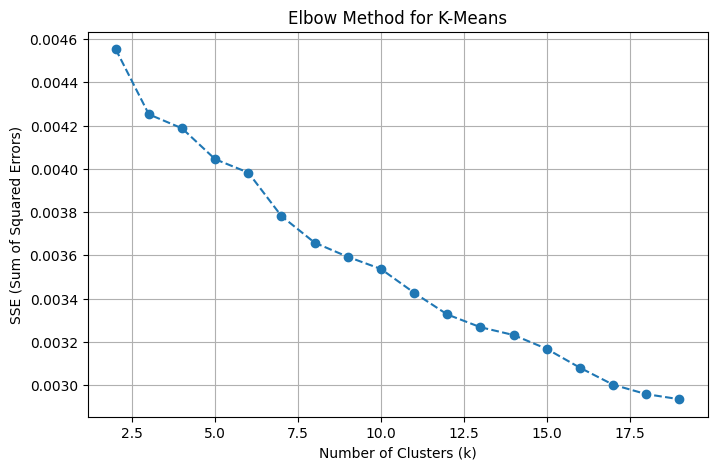

In [26]:
# ✅ Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Sum of Squared Errors)")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

In [27]:
# ✅ Select optimal k
optimal_k = KneeLocator(k_values, sse, curve="convex", direction="decreasing").knee
if optimal_k is None:
    print("⚠️ No clear elbow point found. Using default k = 6")
    optimal_k = 6  # กำหนดค่า k เริ่มต้น

# ✅ Train K-Means with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
word_clusters_kmeans = kmeans.fit_predict(word_vectors)

# ✅ Store clustering results
kmeans_clusters = {words[i]: word_clusters_kmeans[i] for i in range(len(words))}

In [63]:
import sklearn

print(sklearn.__version__) 

1.6.1


In [41]:
# ✅ Compute Cosine Similarity Matrix
word_vectors = normalize(word_vectors)
cosine_sim_matrix = cosine_similarity(word_vectors)

# ✅ Apply Agglomerative Clustering
# agg_clustering = AgglomerativeClustering(
#     n_clusters=None, 
#     distance_threshold=0.7, 
#     metric="precomputed",  # เปลี่ยนจาก affinity เป็น metric
#     linkage="average"
# )
# word_clusters_agg = agg_clustering.fit_predict(1 - cosine_sim_matrix)

for threshold in [0.35, 0.4, 0.5, 0.6, 0.7]:
    dbscan = DBSCAN(eps=threshold, min_samples=2, metric="cosine")  
    word_clusters_dbscan = dbscan.fit_predict(word_vectors)
    print(f"🔹 Clustering with threshold {threshold}: {len(set(word_clusters_dbscan))} clusters")



🔹 Clustering with threshold 0.35: 4 clusters
🔹 Clustering with threshold 0.4: 6 clusters
🔹 Clustering with threshold 0.5: 11 clusters
🔹 Clustering with threshold 0.6: 14 clusters
🔹 Clustering with threshold 0.7: 11 clusters


In [44]:
dbscan = DBSCAN(eps=0.6, min_samples=2, metric="cosine")  
word_clusters_dbscan = dbscan.fit_predict(word_vectors)

# ✅ Store clustering results
agg_clusters = {words[i]: word_clusters_dbscan[i] for i in range(len(words))}


In [ ]:
# for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
#     agg_clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=threshold, linkage="average", metric="precomputed")
#     word_clusters_agg = agg_clustering.fit_predict(1 - cosine_sim_matrix)
#     print(f"🔹 Clustering with threshold {threshold}: {len(set(word_clusters_agg))} clusters")


🔹 Clustering with threshold 0.3: 131 clusters
🔹 Clustering with threshold 0.4: 128 clusters
🔹 Clustering with threshold 0.5: 123 clusters
🔹 Clustering with threshold 0.6: 114 clusters
🔹 Clustering with threshold 0.7: 97 clusters


In [34]:
# ✅ Print top 5 words in each cluster (K-Means)
# print("\n🔹 K-Means Clustering (Euclidean Distance):")
# for cluster_id in set(word_clusters_kmeans):
#     cluster_words = [word for word in words if kmeans_clusters[word] == cluster_id]
#     print(f"Cluster {cluster_id}: {', '.join(cluster_words[:15])} ...")

# ✅ Print top 5 words in each cluster (Agglomerative)
# print("\n🔹 Agglomerative Clustering (Cosine Similarity):")
# for cluster_id in set(word_clusters_dbscan):
#     cluster_words = [word for word in words if agg_clusters[word] == cluster_id]
#     print(f"Cluster {cluster_id}: {', '.join(cluster_words[:5])} ...")


In [45]:
# ✅ Print top 5 words in each cluster (Agglomerative)
print("\n🔹 DBSCAN Clustering (Cosine Similarity):")
for cluster_id in set(word_clusters_dbscan):
    cluster_words = [word for word in words if agg_clusters[word] == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(cluster_words[:15])} ...")


🔹 DBSCAN Clustering (Cosine Similarity):
Cluster 0: nature wildlife area, nature wildlife tour ...
Cluster 1: historic, scenic walking area, historic walking area ...
Cluster 2: boat tour, eco tour, speed boat tour, food tour, night tour, bus tour ...
Cluster 3: history museum, art museum, natural history museum, science museum, military museum, military base facility ...
Cluster 4: architectural building, government building ...
Cluster 5: theme park, state park ...
Cluster 6: hiking trail, hiking camping tour, sightseeing tour, horseback riding tour, climbing tour, walking tour, biking trail ...
Cluster 7: gear rental, boat rental, selfguided tour rental ...
Cluster 8: cultural event, cultural tour ...
Cluster 9: theater, movie theater ...
Cluster 10: private tour, bike tour ...
Cluster 11: jazz club bar, blue club bar ...
Cluster 12: airport shop, airport lounge ...
Cluster -1: other, sacred religious, flea street market, spa, beach, specialty museum, gift specialty shop, waterfall

In [ ]:
# ✅ นับจำนวนกลุ่มที่ได้
# num_clusters = len(set(word_clusters_agg))

# # ✅ นับจำนวนคำที่ไม่ซ้ำกัน
# num_unique_words = len(set(words))

# # ✅ แสดงผล
# print(f"🔹 จำนวนคำที่ไม่ซ้ำกันทั้งหมด: {num_unique_words}")
# print(f"🔹 Agglomerative Clustering (Cosine Similarity) จัดได้ทั้งหมด {num_clusters} กลุ่ม")

🔹 จำนวนคำที่ไม่ซ้ำกันทั้งหมด: 133
🔹 Agglomerative Clustering (Cosine Similarity) จัดได้ทั้งหมด 97 กลุ่ม


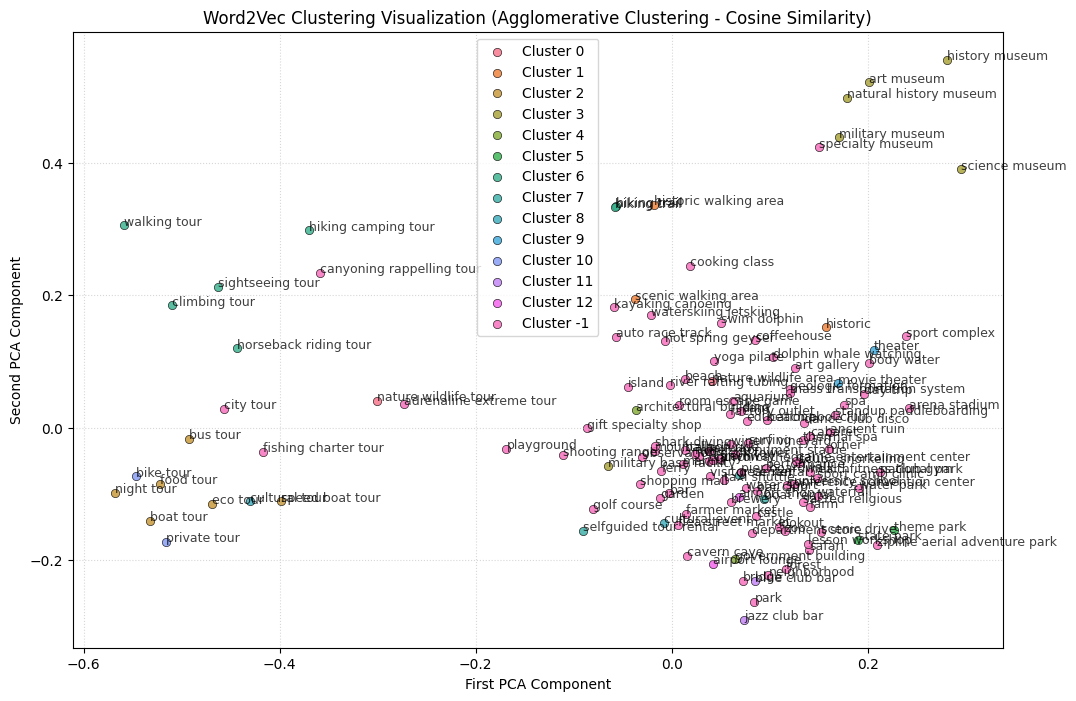

In [46]:
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# ✅ Define colors for clusters
num_clusters = len(set(word_clusters_dbscan))
palette = sns.color_palette("husl", num_clusters)

# ✅ Scatter plot with cluster colors
plt.figure(figsize=(12, 8))
for cluster_id in set(word_clusters_dbscan):
    idx = np.where(word_clusters_dbscan == cluster_id)
    plt.scatter(word_vectors_2d[idx, 0], word_vectors_2d[idx, 1], 
                label=f"Cluster {cluster_id}", color=palette[cluster_id], alpha=0.8, edgecolors='k', linewidth=0.5)

# ✅ Annotate words more clearly
for i, word in enumerate(words):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=9, alpha=0.75)

# ✅ Improve visualization settings
plt.title("Word2Vec Clustering Visualization (Agglomerative Clustering - Cosine Similarity)")
plt.xlabel("First PCA Component")
plt.ylabel("Second PCA Component")
plt.grid(True, linestyle='dotted', alpha=0.5)
plt.legend()
plt.show()

In [47]:
word_vectors[0]

array([-0.03728526, -0.03999581, -0.04012661,  0.05490048, -0.08135836,
       -0.05034336, -0.07670138, -0.0464805 ,  0.01137589, -0.03243056,
        0.06878881,  0.10117141, -0.08748012,  0.01835109, -0.00726747,
       -0.00075135,  0.04020299, -0.01171249, -0.10389724, -0.066068  ,
       -0.11870228, -0.06742235, -0.04690553, -0.0793175 ,  0.06838086,
       -0.05715725, -0.01183549,  0.01206763,  0.02202364, -0.18403433,
        0.04305181, -0.01624133,  0.00328276, -0.0058779 , -0.02906932,
       -0.01544   ,  0.02229483,  0.00831728,  0.01165834,  0.023818  ,
       -0.04129392, -0.00720945, -0.08128852, -0.18294573, -0.07743029,
        0.02569279, -0.03027799,  0.0509643 ,  0.05484145, -0.0308044 ,
        0.02222124, -0.00606077,  0.00228217,  0.01308317, -0.05812236,
       -0.02088233,  0.03906418, -0.07391385, -0.06885599,  0.05405729,
       -0.05419704,  0.01034282, -0.06256031,  0.03571191, -0.00873539,
       -0.02116321, -0.03949353, -0.00972543, -0.07012892,  0.04

In [123]:
for eps in [0.4, 0.5, 0.6, 0.7, 0.8]:
    dbscan = DBSCAN(eps=eps, min_samples=2, metric="cosine")
    word_clusters_dbscan = dbscan.fit_predict(word_vectors)
    num_clusters = len(set(word_clusters_dbscan)) - (1 if -1 in word_clusters_dbscan else 0)
    num_noise = list(word_clusters_dbscan).count(-1)
    
    print(f"🔹 eps = {eps}: {num_clusters} clusters, {num_noise} noise points")


🔹 eps = 0.4: 4 clusters, 125 noise points
🔹 eps = 0.5: 10 clusters, 113 noise points
🔹 eps = 0.6: 12 clusters, 94 noise points
🔹 eps = 0.7: 11 clusters, 69 noise points
🔹 eps = 0.8: 9 clusters, 42 noise points


In [144]:
dbscan = DBSCAN(eps=0.6, min_samples=2, metric="cosine")  
word_clusters_dbscan = dbscan.fit_predict(word_vectors)

# ✅ Store clustering results
agg_clusters = {words[i]: word_clusters_dbscan[i] for i in range(len(words))}


In [145]:
# ✅ Print top 5 words in each cluster (Agglomerative)
print("\n🔹 DBSCAN Clustering (Cosine Similarity):")
for cluster_id in set(word_clusters_dbscan):
    cluster_words = [word for word in words if agg_clusters[word] == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(cluster_words[:15])} ...")


🔹 DBSCAN Clustering (Cosine Similarity):
Cluster 0: specialty museum, history museum, art museum, natural history museum, military museum ...
Cluster 1: nature wildlife area, nature wildlife tour ...
Cluster 2: historic, scenic walking area, historic walking area ...
Cluster 3: boat tour, eco tour, hiking camping tour, sightseeing tour, speed boat tour, bike tour, food tour, night tour, horseback riding tour, city tour, bus tour, climbing tour, walking tour ...
Cluster 4: theme park, state park ...
Cluster 5: hiking trail, biking trail ...
Cluster 6: gear rental, boat rental ...
Cluster 7: water park, water sport ...
Cluster 8: cultural event, cultural tour ...
Cluster 9: theater, movie theater ...
Cluster 10: jazz club bar, blue club bar ...
Cluster 11: airport shop, airport lounge ...
Cluster -1: other, sacred religious, flea street market, spa, beach, gift specialty shop, waterfall, shopping mall, park, bar club, national park, lookout, monument statue, island, cavern cave ...


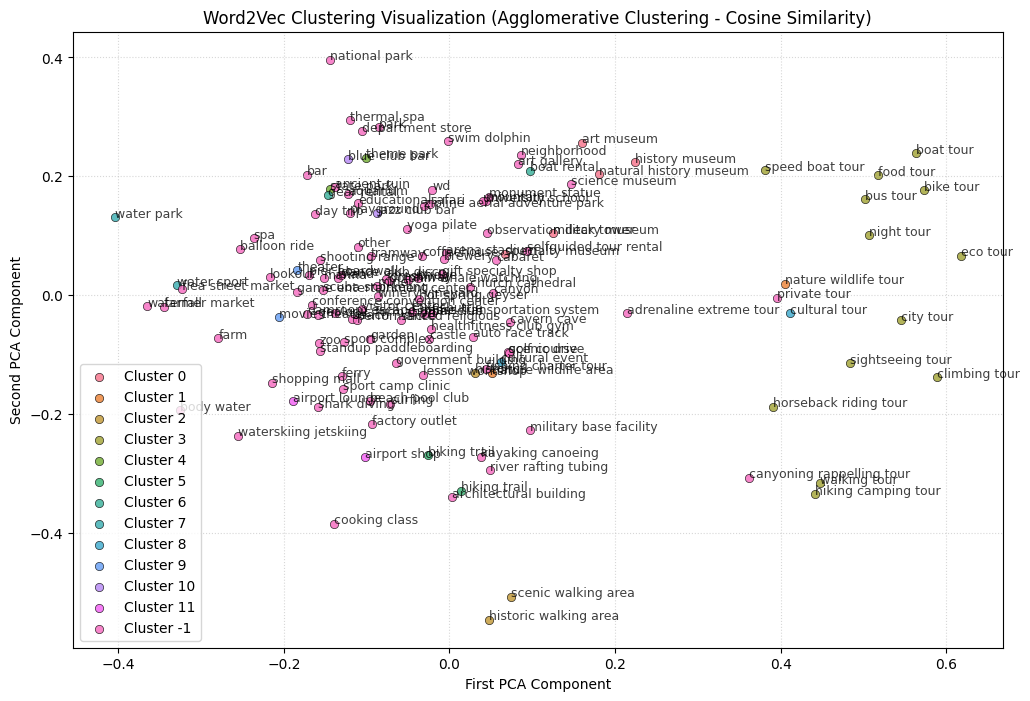

In [146]:
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# ✅ Define colors for clusters
num_clusters = len(set(word_clusters_dbscan))
palette = sns.color_palette("husl", num_clusters)

# ✅ Scatter plot with cluster colors
plt.figure(figsize=(12, 8))
for cluster_id in set(word_clusters_dbscan):
    idx = np.where(word_clusters_dbscan == cluster_id)
    plt.scatter(word_vectors_2d[idx, 0], word_vectors_2d[idx, 1], 
                label=f"Cluster {cluster_id}", color=palette[cluster_id], alpha=0.8, edgecolors='k', linewidth=0.5)

# ✅ Annotate words more clearly
for i, word in enumerate(words):
    plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=9, alpha=0.75)

# ✅ Improve visualization settings
plt.title("Word2Vec Clustering Visualization (Agglomerative Clustering - Cosine Similarity)")
plt.xlabel("First PCA Component")
plt.ylabel("Second PCA Component")
plt.grid(True, linestyle='dotted', alpha=0.5)
plt.legend()
plt.show()

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


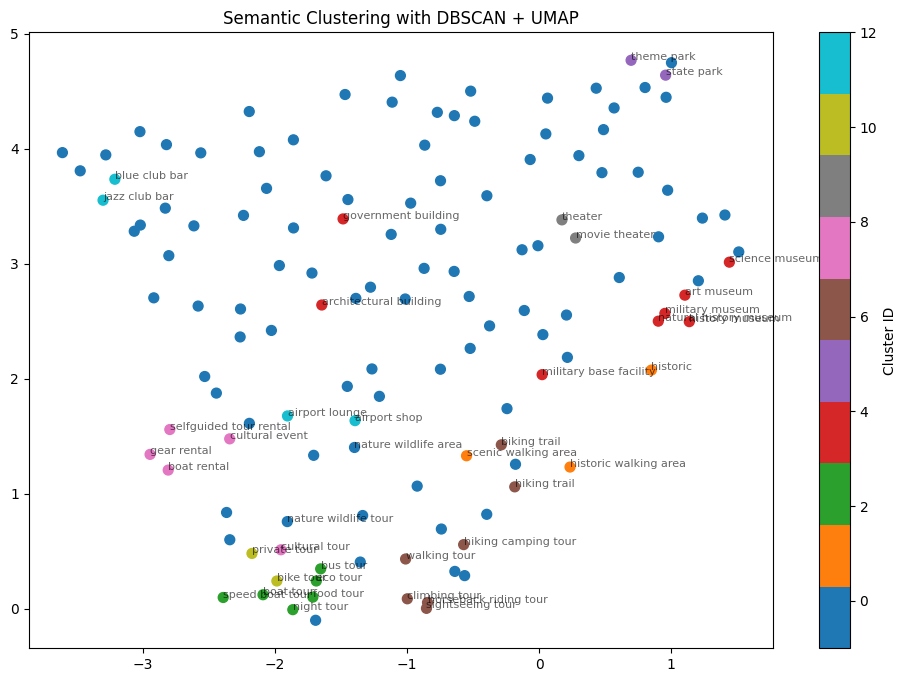

In [50]:
import umap

X = np.array(word_vectors)
labels = np.array(word_clusters_dbscan)

# Reduce dimensions to 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding = reducer.fit_transform(X)

# Plot with cluster colors
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', s=50)

# Optional: Annotate with words
for i, word in enumerate(words):
    if labels[i] != -1:  # -1 = noise
        plt.annotate(word, (embedding[i, 0], embedding[i, 1]), fontsize=8, alpha=0.6)

plt.title("Semantic Clustering with DBSCAN + UMAP")
plt.colorbar(scatter, label='Cluster ID')
plt.show()

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_9392/3607167339.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


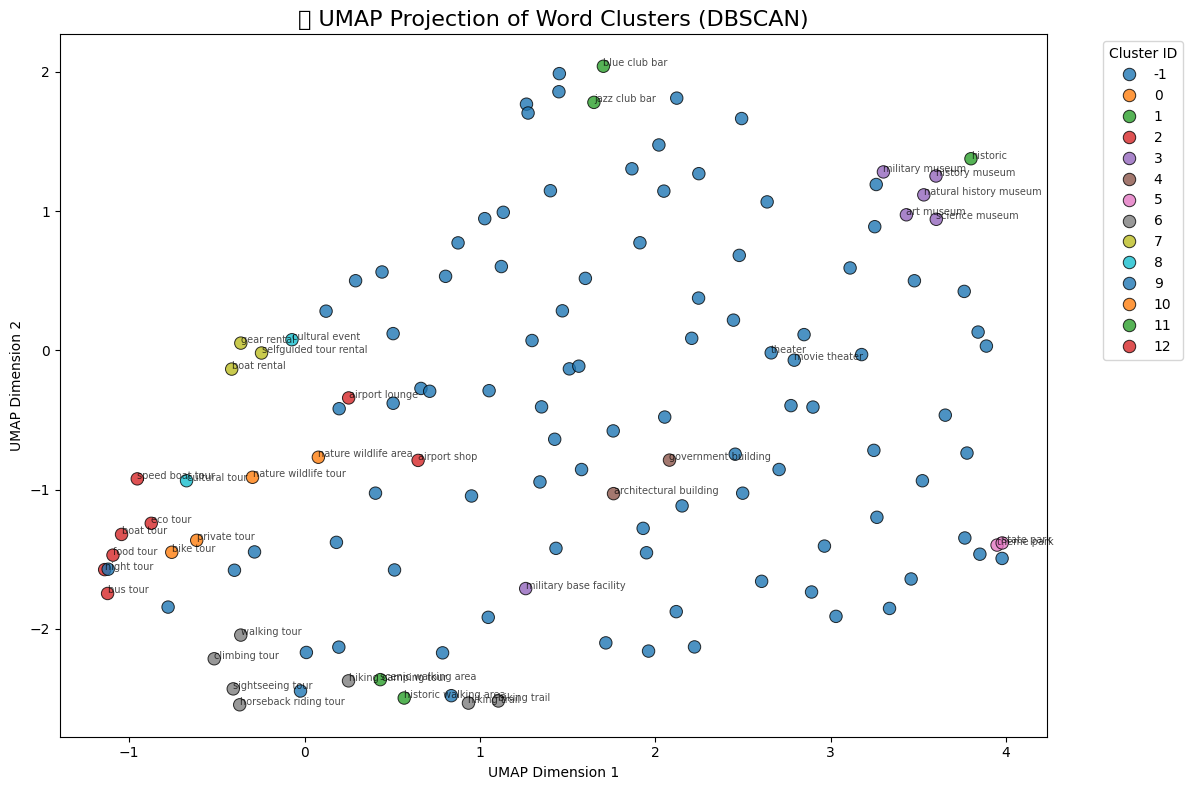

In [56]:
umap_embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine").fit_transform(word_vectors)

# Step 2: Plot clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x=umap_embedding[:, 0], y=umap_embedding[:, 1], hue=word_clusters_dbscan, palette="tab10", s=80, alpha=0.8, edgecolor="k")

# Optional: Annotate words
for i, word in enumerate(words):
    if word_clusters_dbscan[i] != -1:  # skip noise if needed
        plt.text(umap_embedding[i, 0], umap_embedding[i, 1], word, fontsize=7, alpha=0.7)

plt.title("🔍 UMAP Projection of Word Clusters (DBSCAN)", fontsize=16)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [58]:
from collections import defaultdict

cluster_words_dict = defaultdict(list)
for word, label in zip(words, word_clusters_dbscan):
    cluster_words_dict[label].append(word)

# Print top 10 from each cluster
for cid, wlist in cluster_words_dict.items():
    print(f"\n🔹 Cluster {cid} ({len(wlist)} words):\n" + ", ".join(wlist[:10]) + " ...")



🔹 Cluster -1 (92 words):
other, sacred religious, flea street market, spa, beach, specialty museum, gift specialty shop, waterfall, shopping mall, park ...

🔹 Cluster 0 (2 words):
nature wildlife area, nature wildlife tour ...

🔹 Cluster 1 (3 words):
historic, scenic walking area, historic walking area ...

🔹 Cluster 2 (6 words):
boat tour, eco tour, speed boat tour, food tour, night tour, bus tour ...

🔹 Cluster 3 (6 words):
history museum, art museum, natural history museum, science museum, military museum, military base facility ...

🔹 Cluster 4 (2 words):
architectural building, government building ...

🔹 Cluster 5 (2 words):
theme park, state park ...

🔹 Cluster 6 (7 words):
hiking trail, hiking camping tour, sightseeing tour, horseback riding tour, climbing tour, walking tour, biking trail ...

🔹 Cluster 7 (3 words):
gear rental, boat rental, selfguided tour rental ...

🔹 Cluster 8 (2 words):
cultural event, cultural tour ...

🔹 Cluster 9 (2 words):
theater, movie theater ...

🔹

In [49]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Convert Scikit-Learn LDA Model to Gensim Format
tokenized_docs = [text.split() for text in combined_details_df['keyword']]
dictionary = corpora.Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

# Train LDA using Gensim (instead of Scikit-Learn)
lda_model_gensim = LdaModel(corpus=corpus, id2word=dictionary, num_topics=optimal_topics, passes=10)

vis = gensimvis.prepare(lda_model_gensim, corpus, dictionary)
pyLDAvis.display(vis)


AttributeError: 'NoneType' object has no attribute 'split'

🔹 Optimal eps: 0.8802258968353271


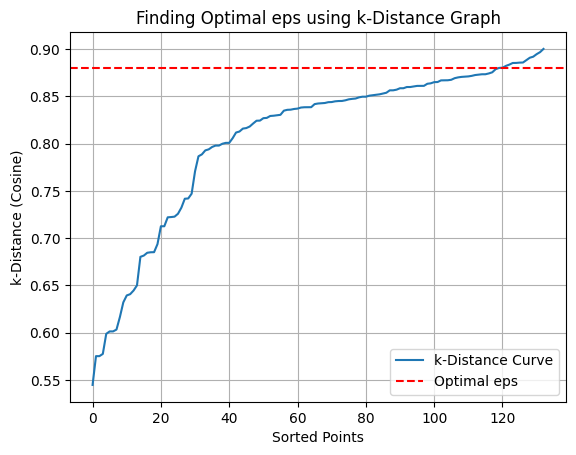

In [132]:
from sklearn.neighbors import NearestNeighbors

k = 5  # ค่า k ควรเท่ากับ min_samples
nbrs = NearestNeighbors(n_neighbors=k, metric="cosine").fit(word_vectors)
distances, indices = nbrs.kneighbors(word_vectors)

# ✅ นำระยะห่างของเพื่อนบ้านอันดับที่ k มาพล็อตกราฟ
distances = np.sort(distances[:, k-1])  # เรียงลำดับค่า
optimal_eps = distances[int(len(distances) * 0.9)]  # เลือกค่าที่สูงสุด 90%
print(f"🔹 Optimal eps: {optimal_eps}")
plt.plot(distances, label="k-Distance Curve")
plt.axhline(y=optimal_eps, color="r", linestyle="--", label="Optimal eps")  # เส้นสีแดง
plt.ylabel("k-Distance (Cosine)")
plt.xlabel("Sorted Points")
plt.title("Finding Optimal eps using k-Distance Graph")
plt.grid()
plt.legend()
plt.show()


In [151]:
# ✅ Map DBSCAN clustering results to `combined_details_df['cluster']`
word_to_cluster = {word: cluster_id for word, cluster_id in zip(words, word_clusters_dbscan)}

# Function to assign cluster labels to `combined_details_df`
def assign_cluster(tags):
    tag_list = tags.split(", ")  # Convert tag string to list
    cluster_ids = [word_to_cluster.get(tag, -1) for tag in tag_list]  # Get clusters, default to -1 if not found
    
    # Return the most common cluster in case multiple tags belong to different clusters
    return max(set(cluster_ids), key=cluster_ids.count) if cluster_ids else -1  

# ✅ Apply function to assign clusters
combined_details_df['cluster'] = combined_details_df['label'].apply(assign_cluster)

In [148]:
# ✅ Filter rows where 'label' contains the word 'museum'
filtered_df = combined_details_df[combined_details_df['label'].str.contains('museum', case=False, na=False)]

# ✅ Get unique labels
unique_museum_labels = filtered_df['label'].unique()

# ✅ Display results
print("Unique Museum Labels:", unique_museum_labels)

Unique Museum Labels: ['history museum' 'specialty museum' 'natural history museum' 'art museum'
 'science museum' 'military museum']


In [152]:
combined_details_df[['name', 'label', 'cluster']]

,name,label,cluster
0,House of Opium,history museum,0
1,Opium Bar,bar club,-1
2,Wat Phra That Doi Saket,sacred religious,-1
3,Mae Ping River Cruise,boat tour,3
4,Pai River,body water,-1
...,...,...,...
1761,Chao Lao Beach,beach,-1
1762,Chao Lao Fish Bridge,bridge,-1
1763,Wat Burapa Temple,sacred religious,-1
1764,Kung Wiman Beach,beach,-1


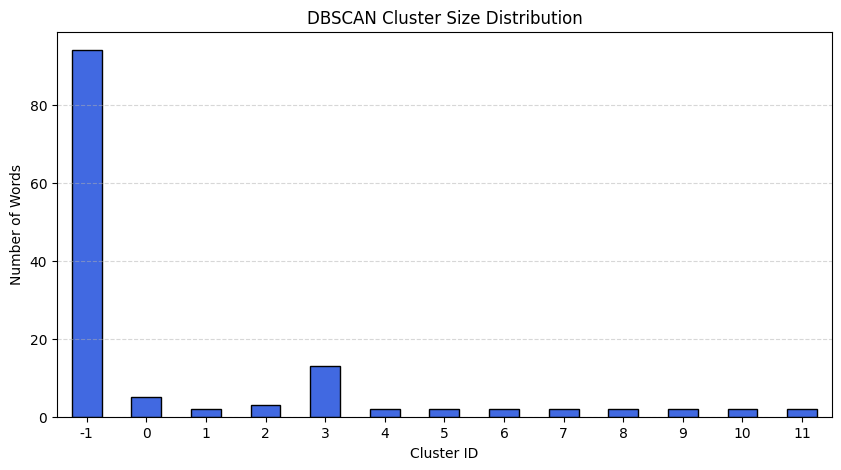

In [153]:

# ✅ Count cluster sizes
cluster_counts = pd.Series(word_clusters_dbscan).value_counts()

# ✅ Bar chart of cluster sizes
plt.figure(figsize=(10, 5))
cluster_counts.sort_index().plot(kind="bar", color="royalblue", edgecolor="black")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Words")
plt.title("DBSCAN Cluster Size Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

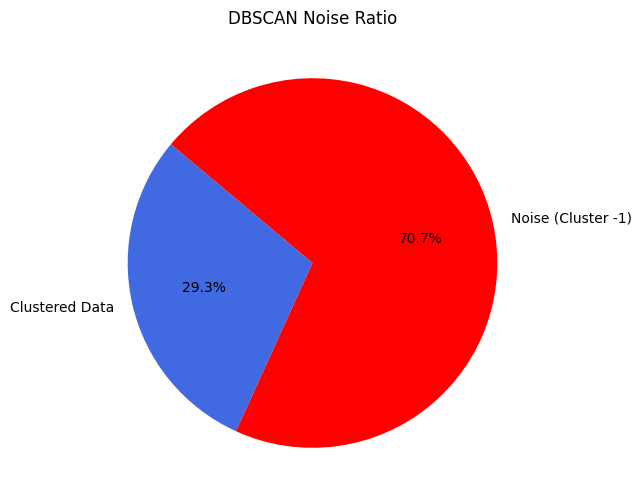

In [154]:
# ✅ Count noise vs. clustered points
num_noise = list(word_clusters_dbscan).count(-1)
num_clustered = len(word_clusters_dbscan) - num_noise

# ✅ Pie chart
plt.figure(figsize=(6, 6))
plt.pie([num_clustered, num_noise], labels=["Clustered Data", "Noise (Cluster -1)"], 
        autopct="%1.1f%%", colors=["royalblue", "red"], startangle=140)
plt.title("DBSCAN Noise Ratio")
plt.show()

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_57400/4015554776.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=word_clusters_dbscan, y=silhouette_vals, palette="husl")


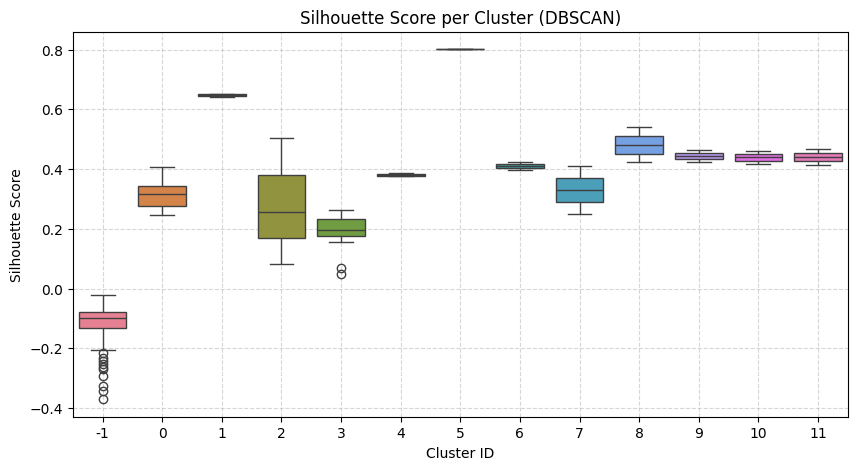

In [156]:
silhouette_vals = silhouette_samples(word_vectors, word_clusters_dbscan, metric="cosine")

# ✅ Box plot of silhouette scores
plt.figure(figsize=(10, 5))
sns.boxplot(x=word_clusters_dbscan, y=silhouette_vals, palette="husl")
plt.xlabel("Cluster ID")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per Cluster (DBSCAN)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

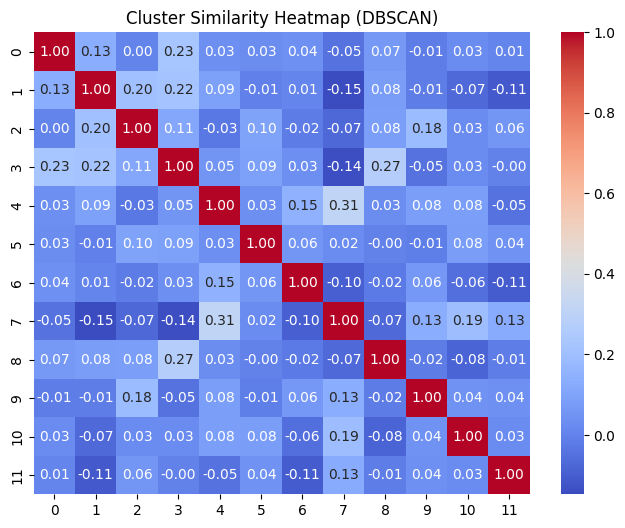

In [157]:
# ✅ Compute average cluster embeddings
cluster_vectors = []
for cluster_id in set(word_clusters_dbscan):
    if cluster_id != -1:  # Ignore noise
        cluster_vectors.append(np.mean([word_vectors[i] for i in range(len(word_clusters_dbscan)) if word_clusters_dbscan[i] == cluster_id], axis=0))

# ✅ Compute similarity matrix
cluster_sim_matrix = cosine_similarity(cluster_vectors)

# ✅ Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cluster_sim_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cluster Similarity Heatmap (DBSCAN)")
plt.show()

In [158]:
combined_details_df.to_parquet("output/cosine_clusters.parquet", index=False)